In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#setting up the dataset
ani = pd.read_csv("data_set/animes.csv")
ani.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19311 entries, 0 to 19310
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   uid         19311 non-null  int64  
 1   title       19311 non-null  object 
 2   synopsis    18336 non-null  object 
 3   genre       19311 non-null  object 
 4   aired       19311 non-null  object 
 5   episodes    18605 non-null  float64
 6   members     19311 non-null  int64  
 7   popularity  19311 non-null  int64  
 8   ranked      16099 non-null  float64
 9   score       18732 non-null  float64
 10  img_url     19131 non-null  object 
 11  link        19311 non-null  object 
dtypes: float64(3), int64(3), object(6)
memory usage: 1.8+ MB


In [13]:
#checking the null and duplicate counts
null = ani.isna().sum()
duplicate = ani.duplicated().sum()

print(f"Null Counts:\n{null}")
print(f"Duplicate COunt:{duplicate}")
print(ani.columns)

Null Counts:
uid           0
title         0
synopsis      0
genre         0
aired         0
episodes      0
members       0
popularity    0
ranked        0
score         0
img_url       0
link          0
dtype: int64
Duplicate COunt:0
Index(['uid', 'title', 'synopsis', 'genre', 'aired', 'episodes', 'members',
       'popularity', 'ranked', 'score', 'img_url', 'link'],
      dtype='object')


In [12]:
#replacing the null values with appropriate ones
ani['synopsis'] = ani['synopsis'].fillna('No synopsis available')
ani['ranked'] = ani['ranked'].fillna('Not Ranked')
ani['img_url'] = ani['img_url'].fillna('No URL available')
ani['episodes'] = ani['episodes'].fillna(0)
ani['score'] = ani['score'].fillna(0)

#dropping the duplicate rows
ani = ani.drop_duplicates().reset_index(drop=True)

In [ ]:
#seperating numeric and non numeric columns
numeric = ani.select_dtypes(include=np.number).columns.tolist()
non_numeric = ani.select_dtypes(exclude=np.number).columns.tolist()



In [28]:
print(ani[numeric].agg(
    ['min', 'max', 'mean', 'median', 'std']
).T)

ani[numeric].skew()



             min         max          mean    median           std
uid          1.0    40960.00  19920.474707  19952.00  14227.234351
episodes     0.0     3057.00     11.271811      1.00     48.081728
members     25.0  1871043.00  27665.055718   1879.00  93646.766247
popularity   1.0    16338.00   8131.919599   8115.00   4714.683351
score        0.0        9.23      6.193994      6.35      1.377811


uid            0.004966
episodes      31.806516
members        7.602992
popularity     0.010195
score         -2.159894
dtype: float64

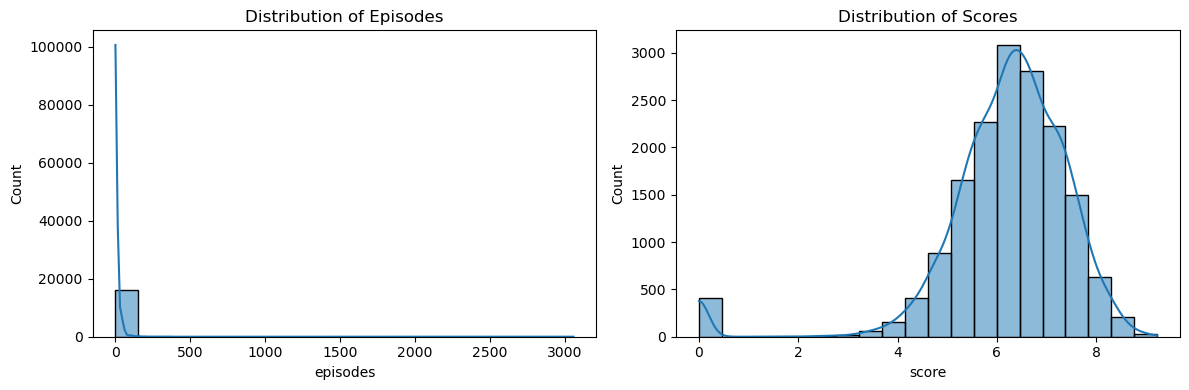

Episodes Skew:31.81  Scores Skew:-2.16


In [48]:
fig, axes = plt.subplots(1,2, figsize = (12,4))
sns.histplot(ani["episodes"],kde=True, bins = 20, ax=axes[0])
axes[0].set_title("Distribution of Episodes")

sns.histplot(ani["score"], kde=True, bins = 20, ax=axes[1])
axes[1].set_title("Distribution of Scores")

plt.tight_layout()
plt.show()
print(f"Episodes Skew:{ani["episodes"].skew():.2f}  Scores Skew:{ani["score"].skew():.2f}")

In [34]:
corr = ani[numeric].corr()
corr

,uid,episodes,members,popularity,score
uid,1.000000,-0.083948,-0.069158,0.370434,-0.318828
episodes,-0.083948,1.000000,0.055385,-0.027875,0.068314
members,-0.069158,0.055385,1.000000,-0.439963,0.292672
popularity,0.370434,-0.027875,-0.439963,1.000000,-0.449973
score,-0.318828,0.068314,0.292672,-0.449973,1.000000


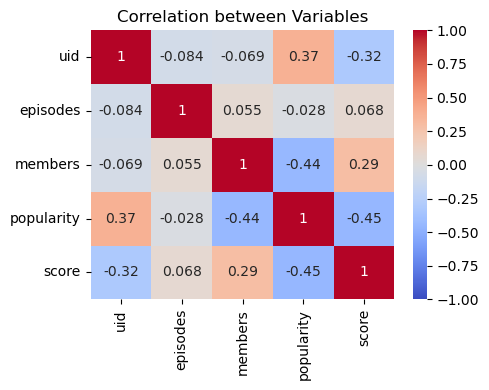

In [35]:
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between Variables")
plt.tight_layout()
plt.show()

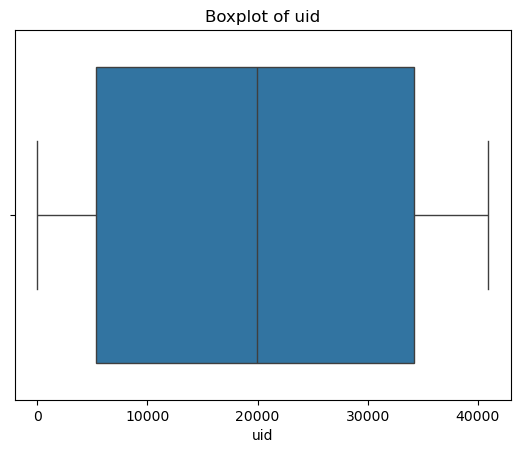

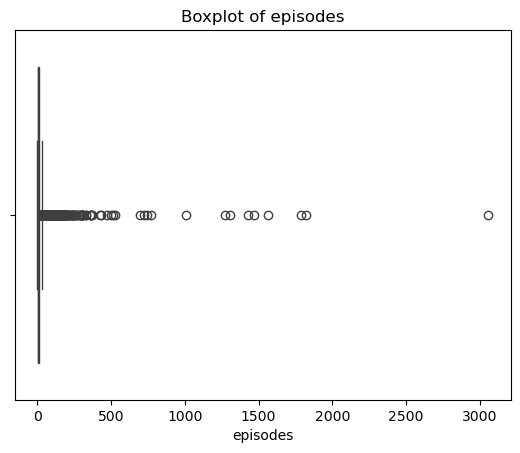

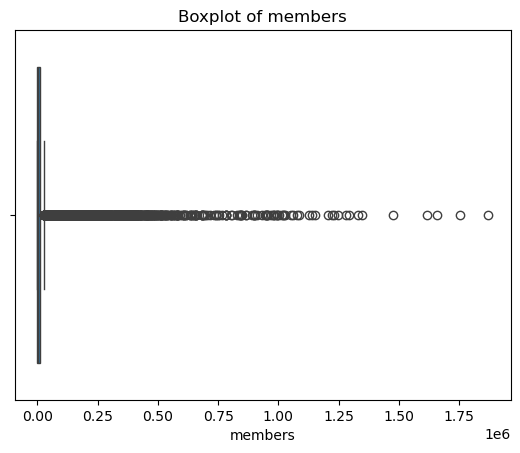

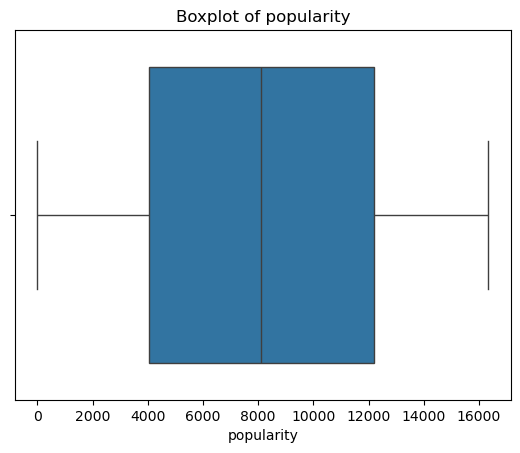

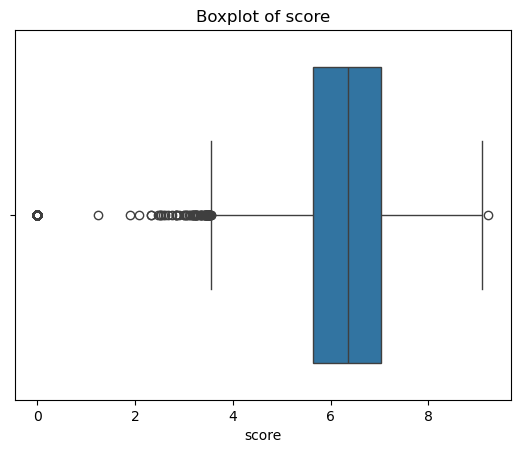

In [38]:
for col in numeric:
    plt.Figure(figsize=(5,4))
    sns.boxplot(x=ani[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

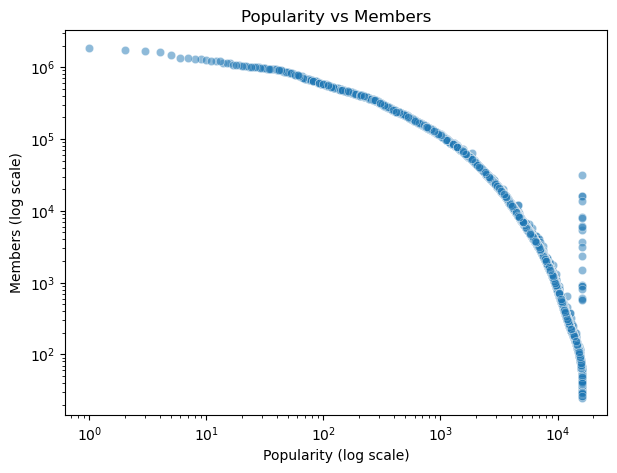

In [39]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=ani, x='popularity', y='members', alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.title('Popularity vs Members')
plt.xlabel('Popularity (log scale)')
plt.ylabel('Members (log scale)')
plt.show()


Insights:

Histogram

1. Episodes is extremely right-skewed (skew ≈ 31.8) — the median is just 1 episode, since most entries are movies, OVAs, or one-off specials, with a long tail stretching out to outliers like a 3057-episode series. Score is left-skewed instead (skew ≈ -2.16) and much more bell-shaped, clustering around 6-7, but the missing values I filled with 0 show up as a small spike near zero rather than spreading the distribution out further.

Heatmap

2. Popularity and members are notably negatively correlated (-0.44), which makes sense once you remember popularity here is a rank, so the more members a show has, the lower (better) its popularity number gets. Score is also negatively correlated with popularity (-0.45), meaning higher-rated anime tend to sit at better popularity ranks, and positively correlated with members (0.29), so anime watched by more people tend to score a bit higher too. Episodes barely correlates with anything (everything under 0.1), so how long a show runs has almost no bearing on how popular or well-rated it is.

Boxplot

3. Members and episodes have by far the most outliers, 2,637 and 1,347 respectively, since a handful of blockbuster or long-running titles dwarf the typical anime (75% of shows have under about 11,900 members, yet the max reaches over 1.8 million). Score has far fewer outliers (478) and popularity has almost none, showing score and popularity are much more evenly spread out than the raw engagement numbers.

Scatter plot

4. On the log-log scatter, popularity and members show a clear negative relationship, as members climbs, popularity rank drops (gets better), confirming what the heatmap suggested. The pattern holds fairly consistently across the whole range on the log scale, meaning even niche anime with a small fanbase follow the same 'more members = better rank' relationship as the mega-popular titles, rather than the two behaving differently at scale.